### CNN 手写数字分类教学版

本实验以 MNIST 手写数字数据集为例，带大家完成一个完整的卷积神经网络分类流程：

1. 加载并预处理图像数据。
2. 构建一个适合入门理解的 CNN 模型。
3. 训练模型并观察损失与准确率变化。
4. 保存模型，并对 testpic 中的图片进行预测。

### 加载 MNIST 数据集，构建并训练最简 CNN 模型

| 步骤 | 关键操作 |
|------|----------|
| ① | **CBA**（Conv + BN + Activation）与 **池化** |
| ② | **view** 或 **flatten** 将特征图展平 |
| ③ | `model.train()` 训练模式 & `model.eval()` 评估模式 |
| ④ | 了解优化器如 SGD、Adam 等(回忆过去，憧憬未来) |


## 示例代码
- 构建CNN模型
- 训练模型
- 评估模型
- 绘制训练过程中的损失曲线和准确率曲线
- 保存模型

使用设备: cpu
加载并预处理数据...
训练集样本数: 60000
测试集样本数: 10000


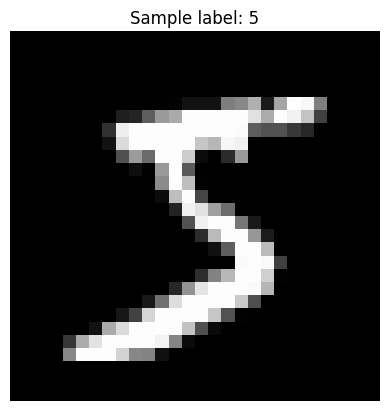

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 固定随机种子，便于课堂上复现实验现象
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# 检查是否有GPU可用
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用设备: {device}')

# 数据路径：优先使用当前目录下已有的本地数据集
MNIST_PATH = './'

# 超参数设置
batch_size = 64
epochs = 3
learning_rate = 0.001

# 数据加载与预处理
print('加载并预处理数据...')

# 定义数据转换
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # 这里的均值和标准差需要与训练和预测保持一致
])

# 加载训练集和测试集；如果本地不存在则自动下载
train_dataset = datasets.MNIST(root=MNIST_PATH, train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root=MNIST_PATH, train=False, download=True, transform=transform)

# 创建数据加载器
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f'训练集样本数: {len(train_dataset)}')
print(f'测试集样本数: {len(test_dataset)}')

# 展示一个样本，帮助同学理解输入数据的样子
sample_image, sample_label = train_dataset[0]
display_image = sample_image.squeeze() * 0.3081 + 0.1307
plt.imshow(display_image, cmap='gray')
plt.title(f'Sample label: {sample_label}')
plt.axis('off')
plt.show()

### 补齐代码，从构建CNN模型开始到保存模型结束

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2304, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
开始训练...
Epoch [1/3], Step [100/938], Loss: 0.4345, Accuracy: 88.08%
Epoch [1/3], Step [200/938], Loss: 0.2704, Accur

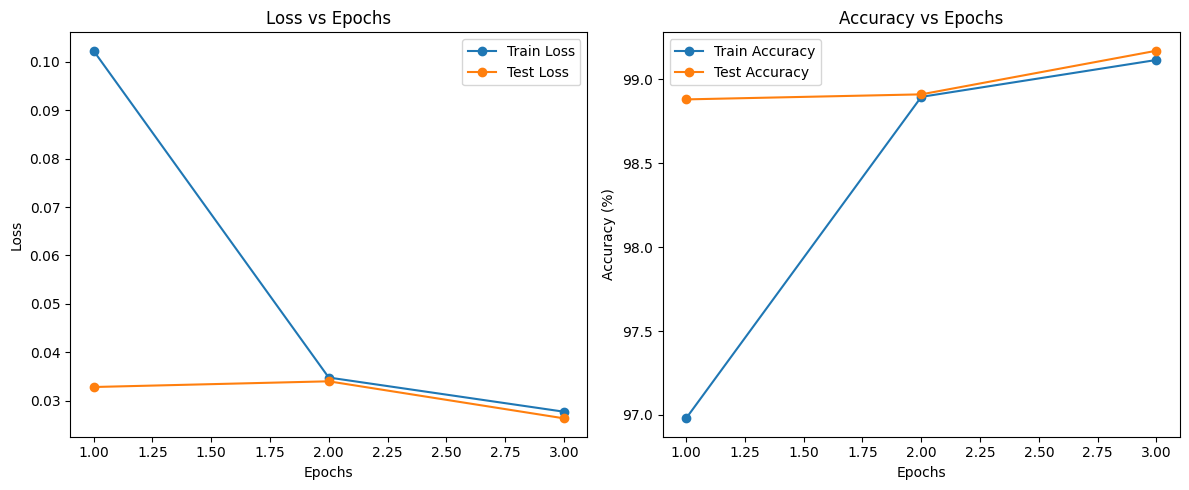

训练结果图表已保存为 training_results.png
模型已保存至 cnn_mnist_model.pth
训练完成！


In [2]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # 第一层卷积层 + BN
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        # 第二层卷积层 + BN
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        # 第三层卷积层 + BN
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        # 第四层卷积层 + BN
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        
        # 池化层
        self.pool = nn.MaxPool2d(2, 2) # 每次池化将特征图尺寸减半
        
        # 全连接层
        self.fc1 = nn.Linear(256 * 3 * 3, 128) # 256个特征图，每个特征图3x3
        self.fc2 = nn.Linear(128, 10) # 10个类别
    
    def forward(self, x):
        # 第一层
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        
        # 第二层
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        
        # 第三层
        x = F.relu(self.bn3(self.conv3(x))) # 注意第三层没有池化，保持特征图尺寸不变
        
        # 第四层
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        
        # 展平
        x = x.view(-1, 256 * 3 * 3)  # 也可以写成 torch.flatten(x, 1)
        
        # 全连接层
        x = F.relu(self.fc1(x))
        x = self.fc2(x)  # 返回 logits，训练时可直接送入 CrossEntropyLoss
        
        return x

# 创建模型实例
model = CNN().to(device)
print(model)

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# 训练循环
train_losses = []
train_accs = []
test_losses = []
test_accs = []

print('开始训练...')
for epoch in range(epochs):
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0
    
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        # 梯度清零
        optimizer.zero_grad()
        
        # 前向传播
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # 反向传播和优化
        loss.backward()
        optimizer.step()
        
        # 统计损失
        train_loss_sum += loss.item() * inputs.size(0)
        
        # 统计准确率
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
        
        # 打印训练进度
        if (i + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Step [{i+1}/{len(train_loader)}], Loss: {train_loss_sum/train_total:.4f}, Accuracy: {100.*train_correct/train_total:.2f}%')
    
    # 记录训练损失和准确率
    train_loss_avg = train_loss_sum / len(train_dataset)
    train_acc = 100. * train_correct / train_total
    train_losses.append(train_loss_avg)
    train_accs.append(train_acc)
    
    # 测试模型
    model.eval()
    test_loss_sum = 0.0
    test_correct = 0
    test_total = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            test_loss_sum += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            test_total += labels.size(0)
            test_correct += predicted.eq(labels).sum().item()
    
    # 记录测试损失和准确率
    test_loss_avg = test_loss_sum / len(test_dataset)
    test_acc = 100. * test_correct / test_total
    test_losses.append(test_loss_avg)
    test_accs.append(test_acc)
    
    print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss_avg:.4f}, Train Acc: {train_acc:.2f}%, Test Loss: {test_loss_avg:.4f}, Test Acc: {test_acc:.2f}%')

# 可视化训练结果
print('生成可视化图表...')
plt.figure(figsize=(12, 5))

# 绘制损失曲线
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_losses, marker='o', label='Train Loss')
plt.plot(range(1, epochs+1), test_losses, marker='o', label='Test Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# 绘制准确率曲线
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), train_accs, marker='o', label='Train Accuracy')
plt.plot(range(1, epochs+1), test_accs, marker='o', label='Test Accuracy')
plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.savefig('training_results.png')
plt.show()
print('训练结果图表已保存为 training_results.png')

# 保存模型
model_path = 'cnn_mnist_model.pth'
torch.save(model.state_dict(), model_path) # 保存模型参数
print(f'模型已保存至 {model_path}')

print('训练完成！')

### 预测脚本

教学提示：

1. 训练阶段和预测阶段都要使用与训练集一致的归一化参数。
2. 如果希望展示“每个类别的概率”，可以在推理阶段额外使用 softmax。
3. 如果只是取预测类别，直接对 logits 做 `argmax` 即可。

已加载模型参数: cnn_mnist_model.pth
开始处理图片...
图片: 1_1.png, 预测数字: 1, 真实标签: 1, 置信度: 0.9870
图片: 1_2.png, 预测数字: 1, 真实标签: 1, 置信度: 0.9960
图片: 1_3.png, 预测数字: 1, 真实标签: 1, 置信度: 0.9998
图片: 2_1.png, 预测数字: 2, 真实标签: 2, 置信度: 0.9907
图片: 2_2.png, 预测数字: 2, 真实标签: 2, 置信度: 0.9670


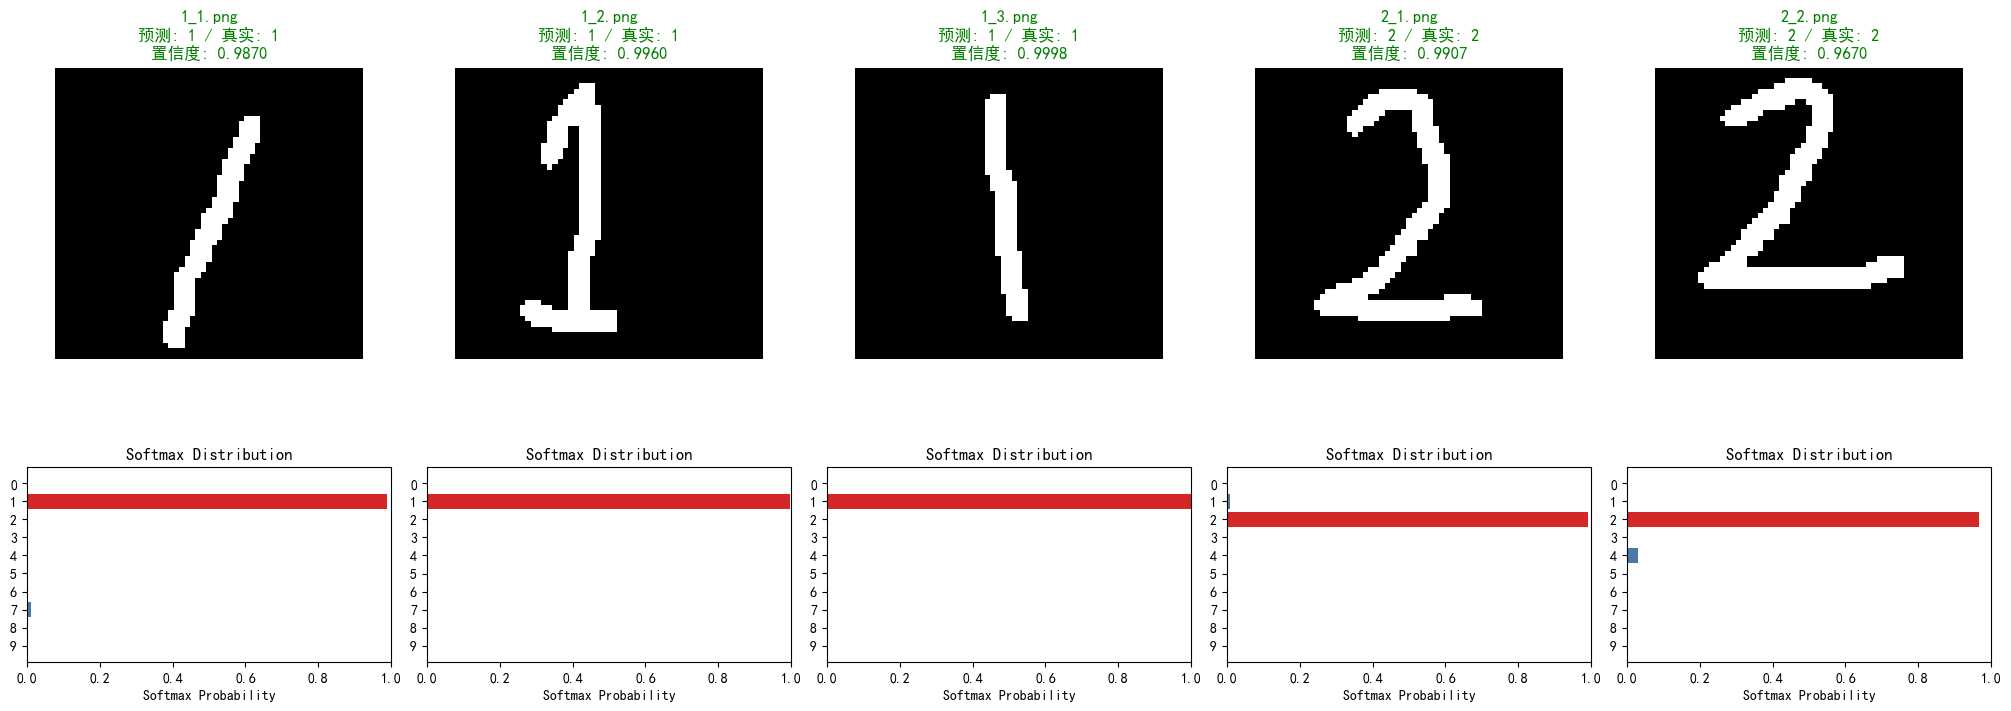

共处理 5 张图片，预测结果与 softmax 分布已显示


In [3]:
from PIL import Image
from matplotlib import gridspec

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

model_path = 'cnn_mnist_model.pth'
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    print(f'已加载模型参数: {model_path}')
else:
    print('未找到已保存模型，将使用当前内存中的模型继续预测。')

model.eval()  # 设置为评估模式

# 定义图像预处理变换；这里必须与训练时保持一致
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# 测试图片目录：优先使用当前目录下的本地测试集
image_dir = './testpic'
# 获取所有图片文件
image_files = sorted([f for f in os.listdir(image_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])

# 预测结果存储
results = []

print('开始处理图片...')
for img_file in image_files:
    img_path = os.path.join(image_dir, img_file)
    
    try:
        # 读取图片
        img = Image.open(img_path).convert('L')  # 转换为灰度图
        original_img = np.array(img)
        
        # 预处理图片
        img_tensor = transform(img).unsqueeze(0).to(device)  # 添加批次维度
        
        # 进行预测
        with torch.no_grad():
            output = model(img_tensor)
            probabilities = torch.softmax(output, dim=1).squeeze(0).cpu().numpy()  # softmax 只用于展示每个类别的概率分布
            predicted = int(np.argmax(probabilities))
            confidence = float(np.max(probabilities))
        
        # 从文件名前缀提取真实标签（如果有）
        true_label = None
        if '_' in img_file:
            prefix = img_file.split('_')[0]
            if prefix.isdigit():
                true_label = int(prefix)
        
        # 保存结果
        results.append((img_file, original_img, predicted, confidence, true_label, probabilities))
        if true_label is None:
            print(f'图片: {img_file}, 预测数字: {predicted}, 置信度: {confidence:.4f}')
        else:
            print(f'图片: {img_file}, 预测数字: {predicted}, 真实标签: {true_label}, 置信度: {confidence:.4f}')
        
    except Exception as e:
        print(f'处理图片 {img_file} 时出错: {str(e)}')

# 可视化结果：每张图片下方配一个横向条形图，展示 softmax 概率分布
if results:
    n_images = len(results)
    fig = plt.figure(figsize=(4 * n_images, 7), constrained_layout=True)
    outer = gridspec.GridSpec(1, n_images, figure=fig, wspace=0.6)

    for i, (img_file, img, pred_class, confidence, true_label, probabilities) in enumerate(results):
        inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[i], height_ratios=[3, 2], hspace=0.25)

        ax_img = fig.add_subplot(inner[0])
        ax_img.imshow(img, cmap='gray')
        if true_label is None:
            title = f'{img_file}\n预测: {pred_class}\n置信度: {confidence:.4f}'
            title_color = 'black'
        else:
            title = f'{img_file}\n预测: {pred_class} / 真实: {true_label}\n置信度: {confidence:.4f}'
            title_color = 'green' if pred_class == true_label else 'red'
        ax_img.set_title(title, color=title_color)
        ax_img.axis('off')

        ax_bar = fig.add_subplot(inner[1])
        classes = list(range(10))
        colors = ['#d62728' if cls == pred_class else '#4C78A8' for cls in classes]
        ax_bar.barh(classes, probabilities, color=colors)
        ax_bar.set_xlim(0, 1)
        ax_bar.set_yticks(classes)
        ax_bar.invert_yaxis()
        ax_bar.set_xlabel('Softmax Probability')
        ax_bar.set_title('Softmax Distribution')

    plt.show()
    print(f'共处理 {n_images} 张图片，预测结果与 softmax 分布已显示')
else:
    print('未找到或无法处理任何图片')

### 特征图可视化
CNN到底看到了什么？让我们看看它在各层中的特征图变化。

请同学重点关注这几件事：

1. 输入图片是 1 × 28 × 28，进入网络后，通道数会逐层增加，空间尺寸会逐层变小。
2. 浅层特征图通常保留较多边缘、笔画、明暗变化等局部信息，看起来更像原图的“局部放大版”。
3. 深层特征图会越来越抽象，不再像原图，而是更像模型对“这个数字应该长什么样”的响应模式。
4. 同一层不同通道关注的内容并不相同，有的更敏感于竖线，有的更敏感于弧线或交叉笔画。
5. 池化会降低分辨率，但会保留更稳定、更重要的响应区域，这也是尺寸变小但信息不一定变少的原因。

建议大家对照第 10 单元思考两个问题：

1. 哪一层的特征图最接近原始图像，为什么？
2. 哪一层的特征图已经明显看不出原图轮廓，但仍然能帮助分类，为什么？

已加载模型参数: cnn_mnist_model.pth
随机样本索引: 1824
真实标签: 2, 预测标签: 2
各层张量尺寸变化:
输入: (1, 1, 28, 28)
第1层输出: (1, 32, 14, 14)
第2层输出: (1, 64, 7, 7)
第3层输出: (1, 128, 7, 7)
第4层输出: (1, 256, 3, 3)
展平后: (1, 2304)


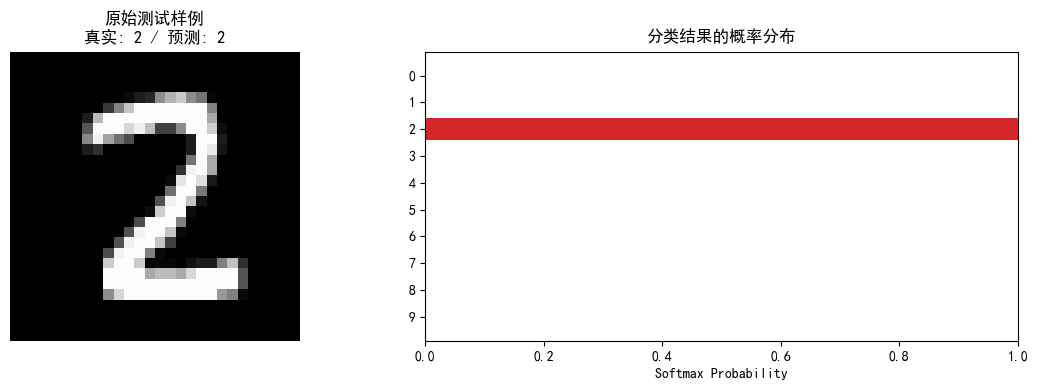

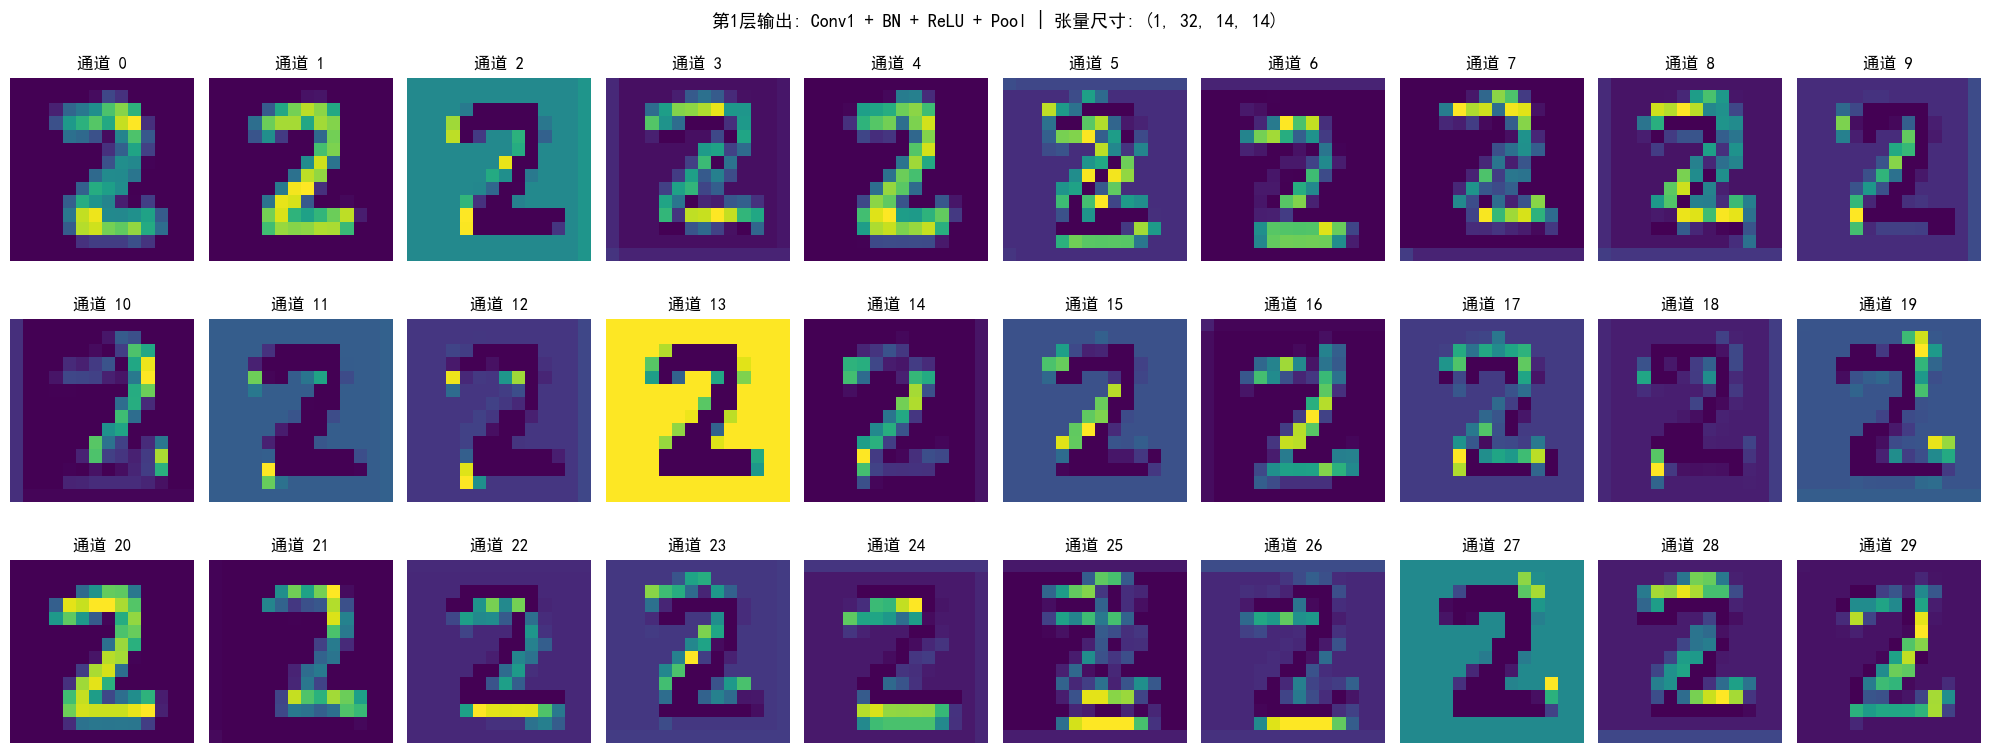

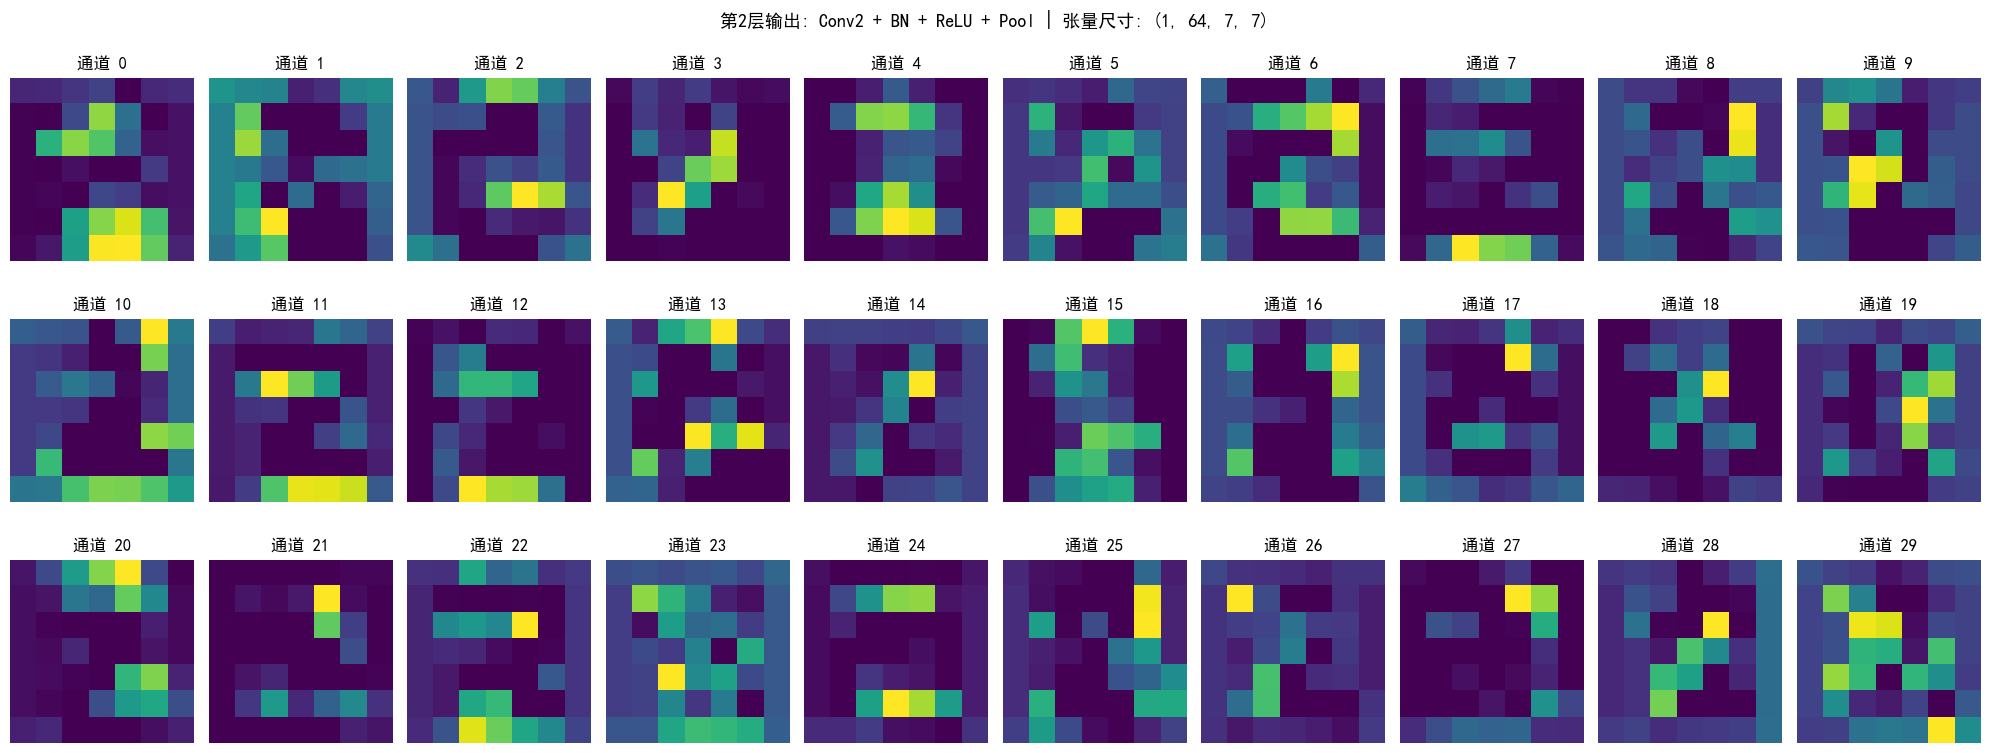

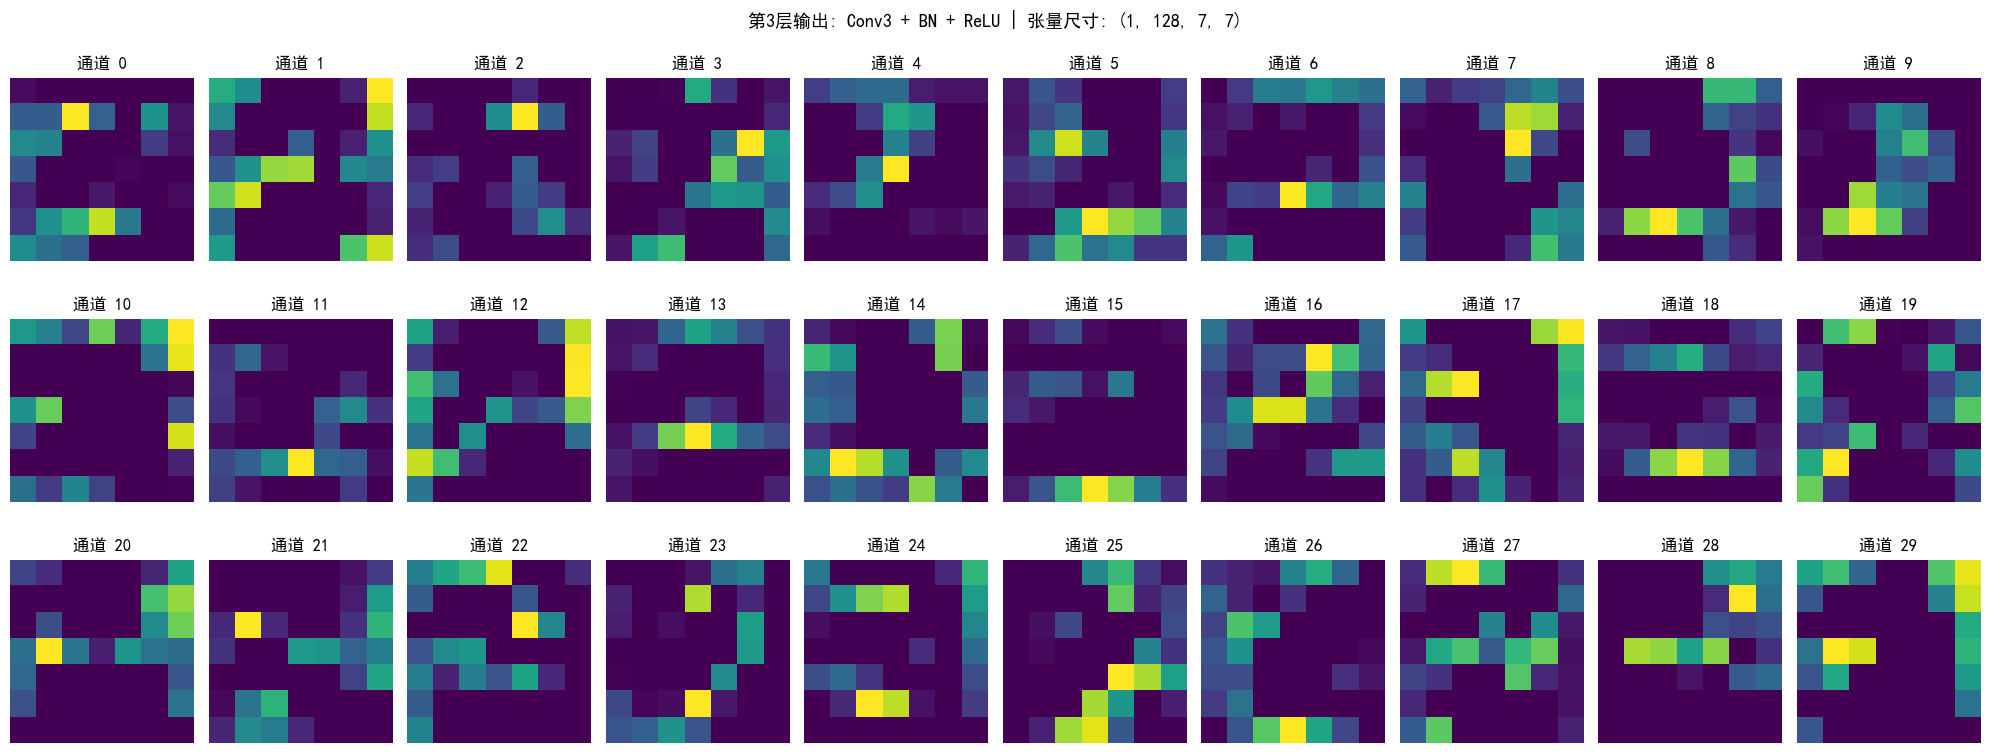

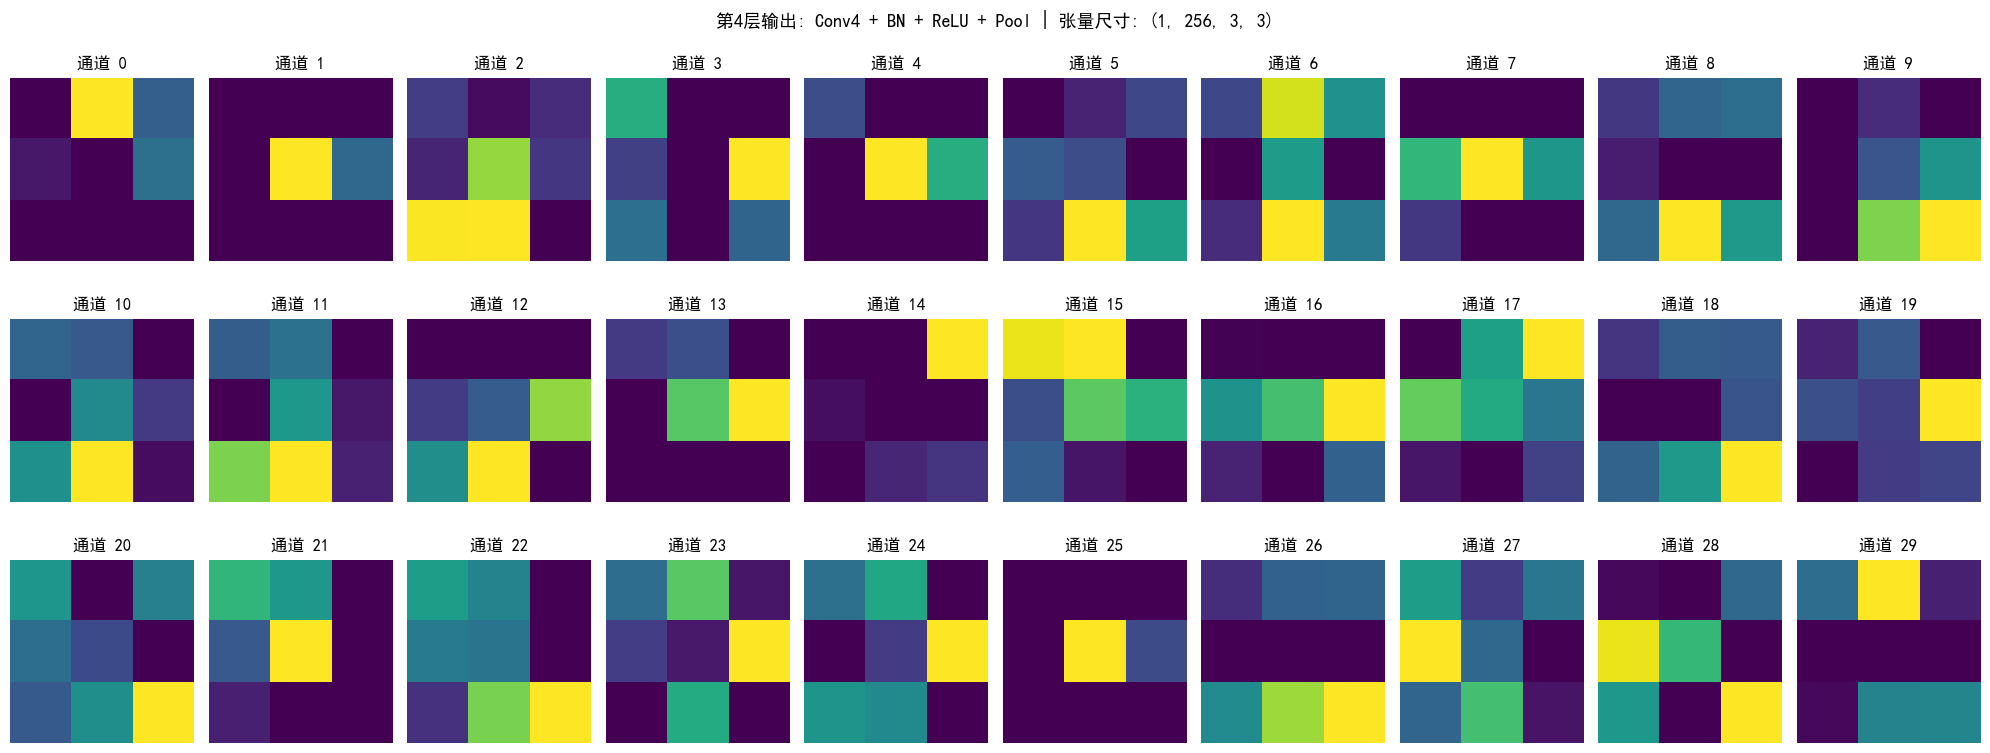

In [4]:
### 特征图可视化

if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    print(f'已加载模型参数: {model_path}')
else:
    print('未找到已保存模型，将使用当前内存中的模型进行特征图可视化。')

model.eval()

# 从测试集中随机抽取一张样本
sample_index = random.randint(0, len(test_dataset) - 1)
sample_image, sample_label = test_dataset[sample_index]
input_tensor = sample_image.unsqueeze(0).to(device)

with torch.no_grad():
    feature_1 = model.pool(F.relu(model.bn1(model.conv1(input_tensor))))
    feature_2 = model.pool(F.relu(model.bn2(model.conv2(feature_1))))
    feature_3 = F.relu(model.bn3(model.conv3(feature_2)))
    feature_4 = model.pool(F.relu(model.bn4(model.conv4(feature_3))))
    flattened = feature_4.view(feature_4.size(0), -1)
    outputs = model(input_tensor)
    probabilities = torch.softmax(outputs, dim=1).squeeze(0).cpu().numpy()
    pred_label = int(np.argmax(probabilities))

feature_maps = [
    ('第1层输出: Conv1 + BN + ReLU + Pool', feature_1.cpu()),
    ('第2层输出: Conv2 + BN + ReLU + Pool', feature_2.cpu()),
    ('第3层输出: Conv3 + BN + ReLU', feature_3.cpu()),
    ('第4层输出: Conv4 + BN + ReLU + Pool', feature_4.cpu()),
]

print(f'随机样本索引: {sample_index}')
print(f'真实标签: {sample_label}, 预测标签: {pred_label}')
print('各层张量尺寸变化:')
print(f'输入: {tuple(input_tensor.shape)}')
print(f'第1层输出: {tuple(feature_1.shape)}')
print(f'第2层输出: {tuple(feature_2.shape)}')
print(f'第3层输出: {tuple(feature_3.shape)}')
print(f'第4层输出: {tuple(feature_4.shape)}')
print(f'展平后: {tuple(flattened.shape)}')

# 总览图：原图 + 概率分布
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
display_image = input_tensor.squeeze().cpu().numpy() * 0.3081 + 0.1307
axes[0].imshow(display_image, cmap='gray')
axes[0].set_title(f'原始测试样例\n真实: {sample_label} / 预测: {pred_label}')
axes[0].axis('off')

classes = list(range(10))
colors = ['#d62728' if idx == pred_label else '#4C78A8' for idx in classes]
axes[1].barh(classes, probabilities, color=colors)
axes[1].set_xlim(0, 1)
axes[1].set_yticks(classes)
axes[1].invert_yaxis()
axes[1].set_xlabel('Softmax Probability')
axes[1].set_title('分类结果的概率分布')
plt.tight_layout()
plt.show()

# 分层展示：每层单独显示前 30 个通道
for layer_name, feature_tensor in feature_maps:
    fig, axes = plt.subplots(3, 10, figsize=(20, 8))
    channels = min(30, feature_tensor.shape[1])
    fig.suptitle(f"{layer_name} | 张量尺寸: {tuple(feature_tensor.shape)}", fontsize=13)

    for feature_idx, ax_feature in enumerate(axes.flat):
        if feature_idx < channels:
            panel = feature_tensor[0, feature_idx].numpy()
            panel_min = panel.min()
            panel_max = panel.max()
            if panel_max > panel_min:
                panel = (panel - panel_min) / (panel_max - panel_min)
            ax_feature.imshow(panel, cmap='viridis', interpolation='nearest')
            ax_feature.set_title(f'通道 {feature_idx}')
        else:
            ax_feature.set_visible(False)
            continue
        ax_feature.axis('off')

    plt.tight_layout()
    plt.show()

已加载模型参数: cnn_mnist_model.pth


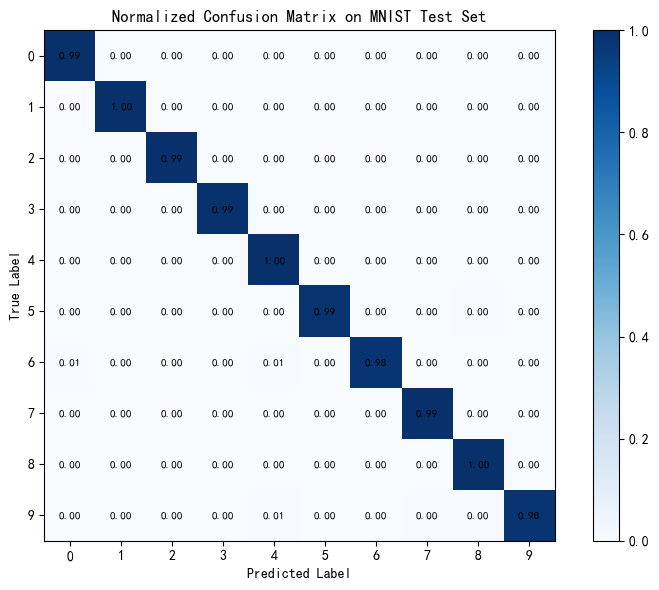

In [5]:
# 归一化混淆矩阵：统计测试集上每个数字的预测情况
model_path = 'cnn_mnist_model.pth'
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    print(f'已加载模型参数: {model_path}')
else:
    print('未找到已保存模型，将使用当前内存中的模型计算混淆矩阵。')

model.eval()
num_classes = 10
confusion = np.zeros((num_classes, num_classes), dtype=int)

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(dim=1)

        for true_label, pred_label in zip(labels.cpu().numpy(), preds.cpu().numpy()):
            confusion[true_label, pred_label] += 1

row_sums = confusion.sum(axis=1, keepdims=True)
confusion_normalized = np.divide(confusion, row_sums, out=np.zeros_like(confusion, dtype=float), where=row_sums != 0)

plt.figure(figsize=(8, 6))
plt.imshow(confusion_normalized, cmap='Blues', vmin=0, vmax=1)
plt.title('Normalized Confusion Matrix on MNIST Test Set')
plt.colorbar()
plt.xticks(range(num_classes), range(num_classes))
plt.yticks(range(num_classes), range(num_classes))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

for row in range(num_classes):
    for col in range(num_classes):
        value = confusion_normalized[row, col]
        plt.text(col, row, f'{value:.2f}', ha='center', va='center', color='black', fontsize=8)

plt.tight_layout()
plt.show()

### 归一化混淆矩阵：查看哪些数字更容易被混淆

除了看整体准确率，我们还可以通过归一化混淆矩阵观察：

1. 哪些数字分类最稳定。
2. 哪些数字最容易相互混淆。
3. 模型错误主要集中在哪些类别对上。